# Context
In this project, I have compared machine learning algorithms with respect to the compressive strength of concrete and its ingredients. The strength of concrete is an extremely important property in construction. The goal is to be able to predict a concrete strength, with as much accuracy as possible, in order to save time, money, and increase safety.

The goal of this project is to train, compare and assess different regression models to determine which regression model is best at predicting a relationship between concrete ingredients (cement, water, aggregates, etc.) and ultimate strength.

I have used many machine learning algorithms throughout this project; including:

Linear Regression

K-Nearest Neighbors (KNN)

Decision Tree Regressor

Random Forest Regressor

XGBoost Regressor

After preprocessing and scaling the data properly, I trained each of these models on metric such as Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score in order to provide an accurate and fair comparison.

In conclusion, this project not only demonstrates the power of machine learning for real-world problems, but how model selection and hyperparameter tuning can affect optimal performance.

# DataSet
 Original Owner and Donor

Prof. I-Cheng Yeh

Department of Information Management

Chung-Hua University

Citation Request:

I-Cheng Yeh, "Modeling of strength of high performance concrete using artificial neural networks," Cement and Concrete Research, Vol. 28, No. 12, pp. 1797-1808 (1998).

# Import Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from sklearn.model_selection import train_test_split,cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

# Data Loading and Inspection

In [3]:
df = pd.read_csv('concrete_data.csv')

# Data Exploration

In [4]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.tail()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


In [6]:
#any missing values
pd.DataFrame(df.isna().sum())

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [8]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
pd.DataFrame(df.Strength.value_counts()).T

Strength,33.40,77.30,79.30,31.35,71.30,35.30,23.52,41.05,44.28,41.54,...,38.77,51.33,56.85,58.61,36.99,47.40,51.96,56.74,17.57,32.77
count,6,4,4,4,4,4,4,4,3,3,...,1,1,1,1,1,1,1,1,1,1


In [10]:
pd.DataFrame(df.Cement.value_counts()).T

Cement,362.6,425.0,251.4,310.0,446.0,331.0,475.0,250.0,349.0,387.0,...,149.5,139.9,151.6,133.1,145.9,236.9,184.0,336.0,260.0,260.9
count,20,20,15,14,14,13,13,13,12,12,...,1,1,1,1,1,1,1,1,1,1


In [11]:
df.groupby(['Strength']).max().sort_values(by='Strength', ascending=False)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
Strength,,,,,,,,
82.60,389.9,189.0,0.0,145.9,22.0,944.7,755.8,91
81.75,315.0,137.0,0.0,145.0,5.9,1130.0,745.0,28
80.20,323.7,282.8,0.0,183.8,10.3,942.7,659.9,56
79.99,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
79.40,389.9,189.0,0.0,145.9,22.0,944.7,755.8,56
...,...,...,...,...,...,...,...,...
4.83,141.3,212.0,0.0,203.5,0.0,971.8,748.5,3
4.78,153.0,102.0,0.0,192.0,0.0,888.0,943.1,3
4.57,102.0,153.0,0.0,192.0,0.0,887.0,942.0,3


In [12]:
df[df.Strength > 30]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1024,166.0,259.7,0.0,183.2,12.7,858.8,826.8,28,37.92
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [13]:
df[df.Age == 28]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


# Exploratory Data Analysis (EDA)

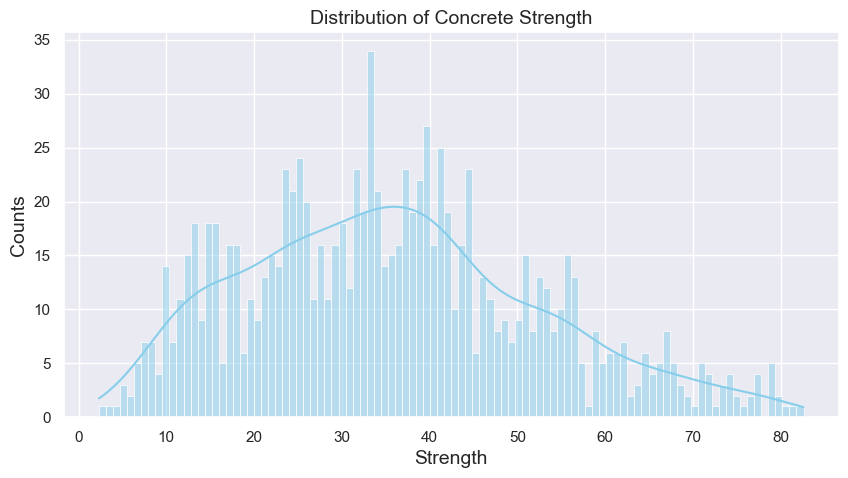

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(x = 'Strength', data = df, bins = 100, kde=True, color = 'skyblue')
plt.xlabel('Strength', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title('Distribution of Concrete Strength', fontsize=14)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_18108\3121969599.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i], bins=50, kde=True, palette='plasma', color = 'gray')
C:\Users\User\AppData\Local\Temp\ipykernel_18108\3121969599.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i], bins=50, kde=True, palette='plasma', color = 'gray')
C:\Users\User\AppData\Local\Temp\ipykernel_18108\3121969599.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i], bins=50, kde=True, palette='plasma', color = 'gray')
C:\Users\User\AppData\Local\Temp\ipykernel_18108\3121969599.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i], bins=50, kde=True, palette='plasma', color = 'gray')
C:\Users\User\AppData\Local\Temp\ipykernel_18108\3121969599.py:6: UserWarning: Ignoring `palette` because no `hue` variable has 

<function matplotlib.pyplot.show(close=None, block=None)>

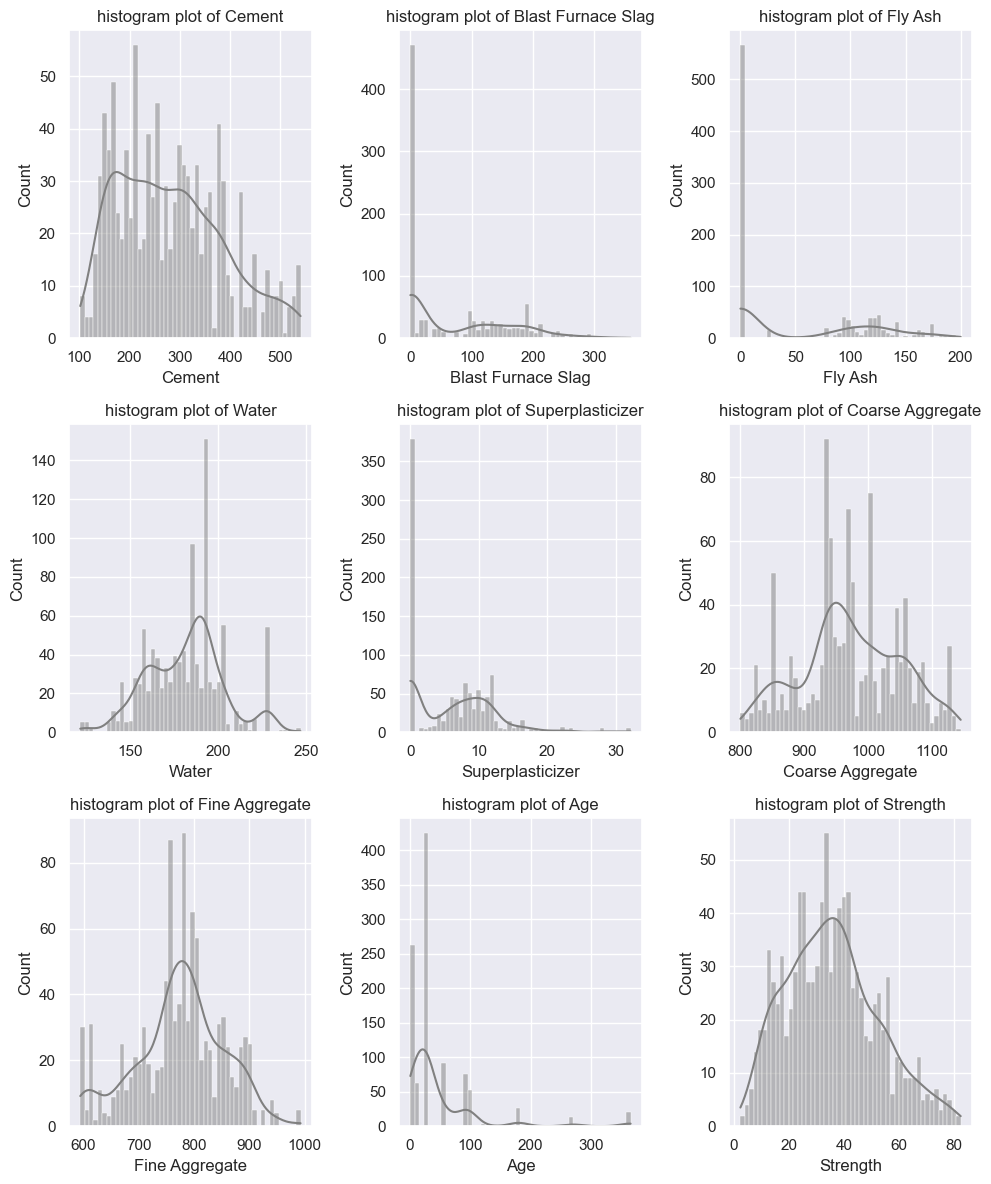

In [15]:
sns.set()
plt.figure(figsize=(10,12))
j = 1
for i in df.columns:
    plt.subplot(3,3,j)
    sns.histplot(df[i], bins=50, kde=True, palette='plasma', color = 'gray')
    plt.title(f'histogram plot of {i}')
    j+=1
plt.tight_layout()
plt.savefig('histogram of features.png' , dpi = 300)
plt.show

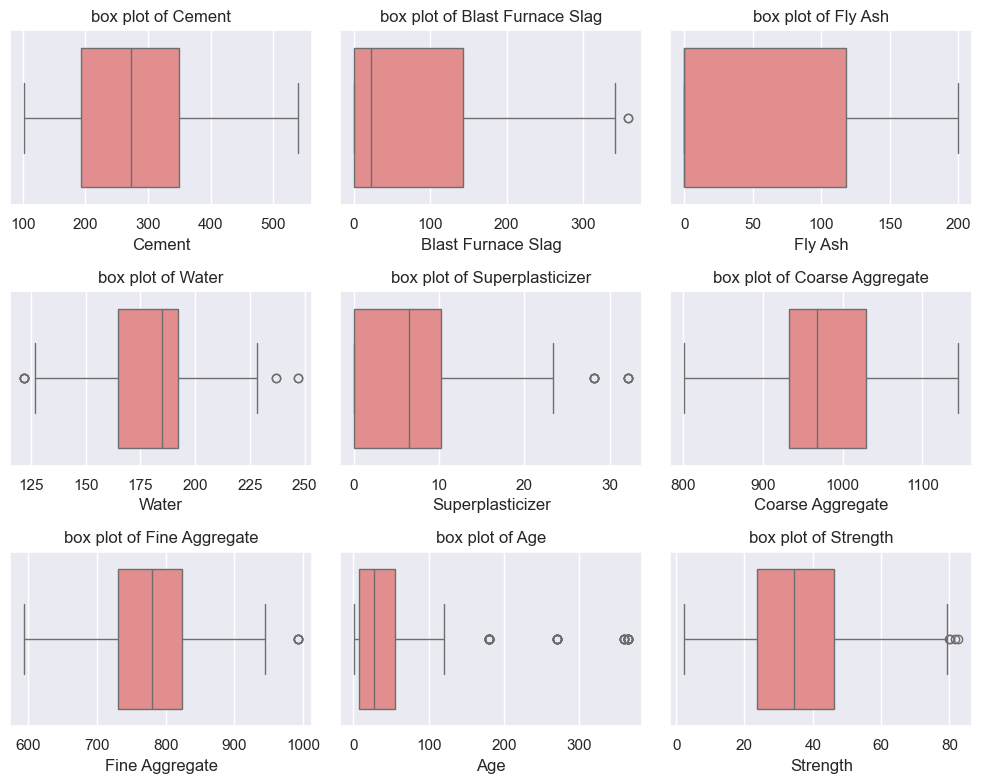

In [16]:
plt.figure(figsize=(10,8))
for i, col in enumerate(df.columns,1):
    plt.subplot(3,3,i)
    sns.boxplot(x = col, data=df, color='lightcoral')
    plt.title(f'box plot of {col}')
plt.tight_layout()
plt.show()

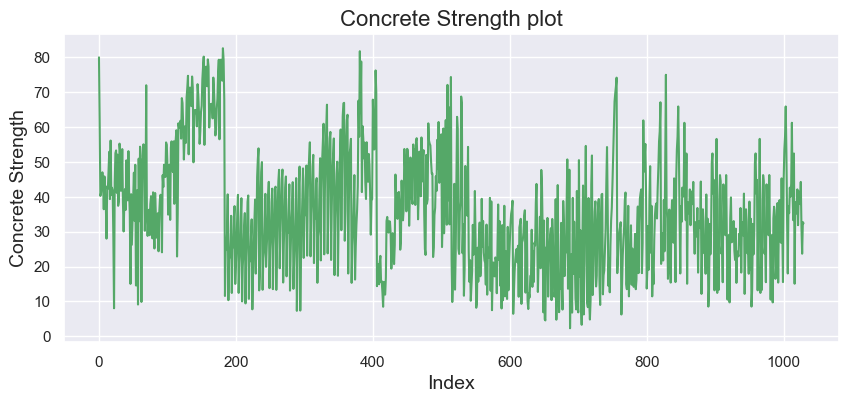

In [17]:
plt.figure(figsize=(10,4))
plt.plot(df.Strength.index, df.Strength, color='g')
plt.title('Concrete Strength plot', fontsize=16)
plt.xlabel('Index', fontsize=14)
plt.ylabel('Concrete Strength', fontsize=14)
plt.show()

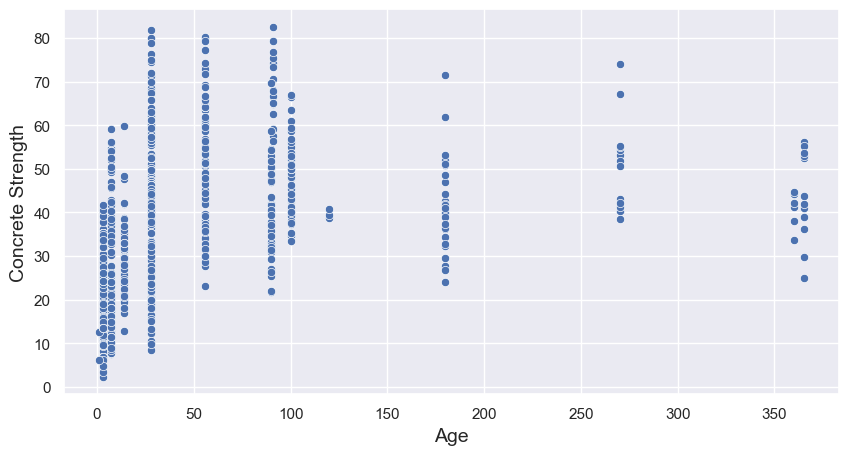

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = 'Age', y = 'Strength', data = df, marker = 'o', c = 'b')
plt.xlabel('Age', fontsize=14)
plt.ylabel('Concrete Strength', fontsize=14)
plt.show()

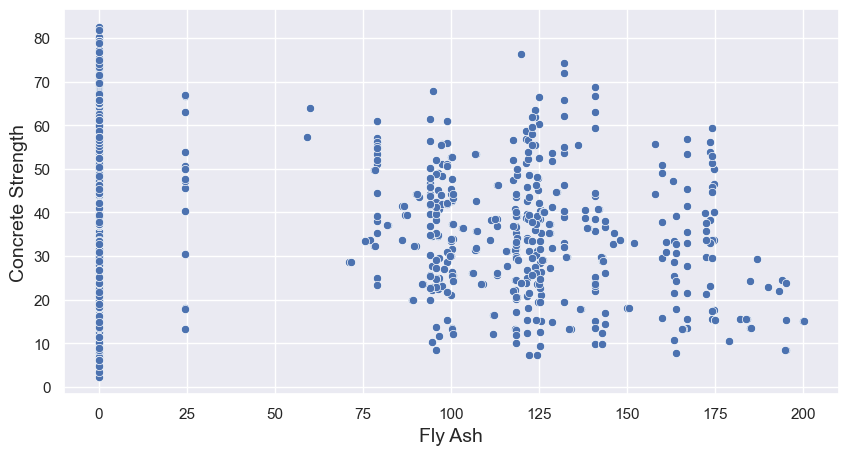

In [19]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = 'Fly Ash', y = 'Strength', data = df, marker = 'o', c = 'b')
plt.xlabel('Fly Ash', fontsize=14)
plt.ylabel('Concrete Strength', fontsize=14)
plt.show()

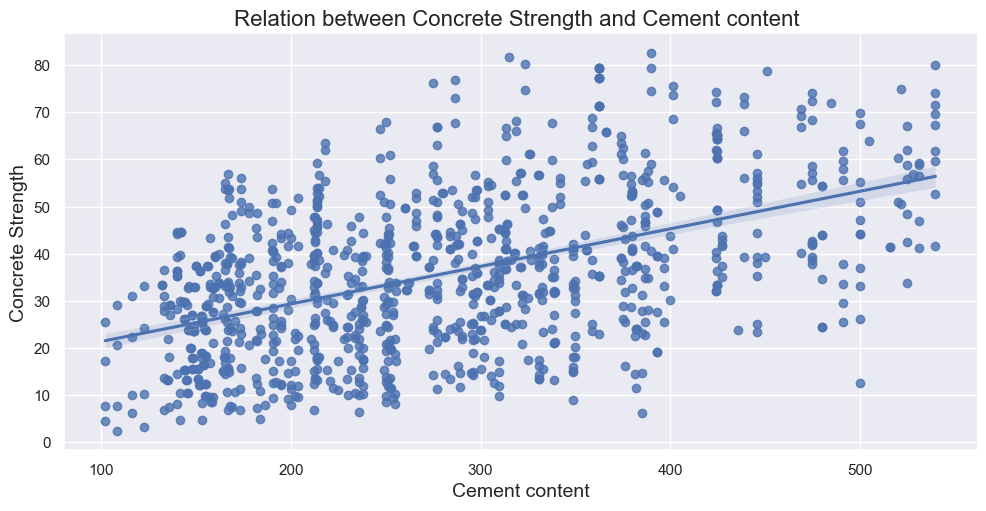

In [20]:
sns.lmplot(x = 'Cement', y = 'Strength', data = df, height = 5, aspect = 2, markers = 'o')
plt.title('Relation between Concrete Strength and Cement content ', fontsize=16)
plt.xlabel('Cement content', fontsize=14)
plt.ylabel('Concrete Strength', fontsize=14)
plt.show()

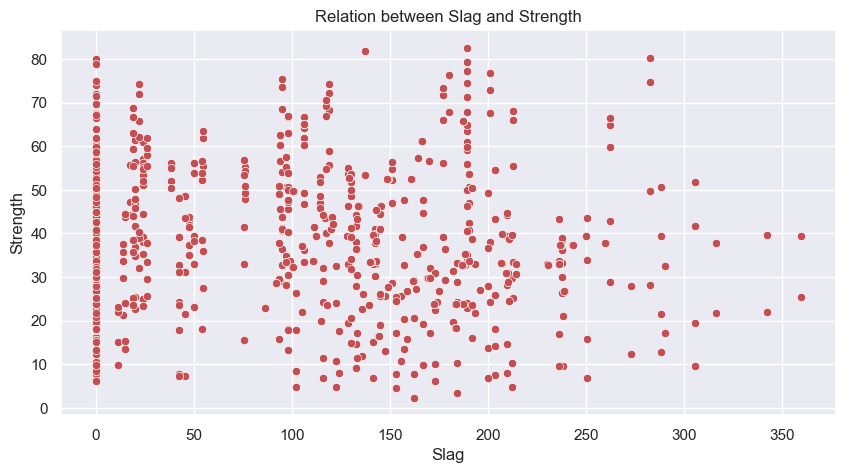

In [21]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = 'Blast Furnace Slag', y = 'Strength', data = df, color = 'r')
plt.title('Relation between Slag and Strength')
plt.xlabel('Slag')
plt.ylabel('Strength')
plt.show()

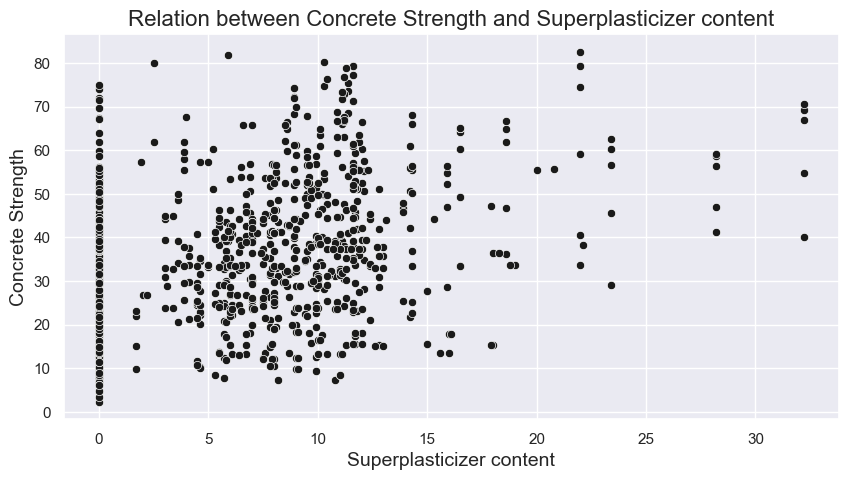

In [22]:
plt.figure(figsize=(10, 5))  
sns.scatterplot(x='Superplasticizer', y='Strength', data=df, marker= 'o' , color='k')
plt.title('Relation between Concrete Strength and Superplasticizer content', fontsize=16)
plt.xlabel('Superplasticizer content', fontsize=14)
plt.ylabel('Concrete Strength', fontsize=14)
plt.show()

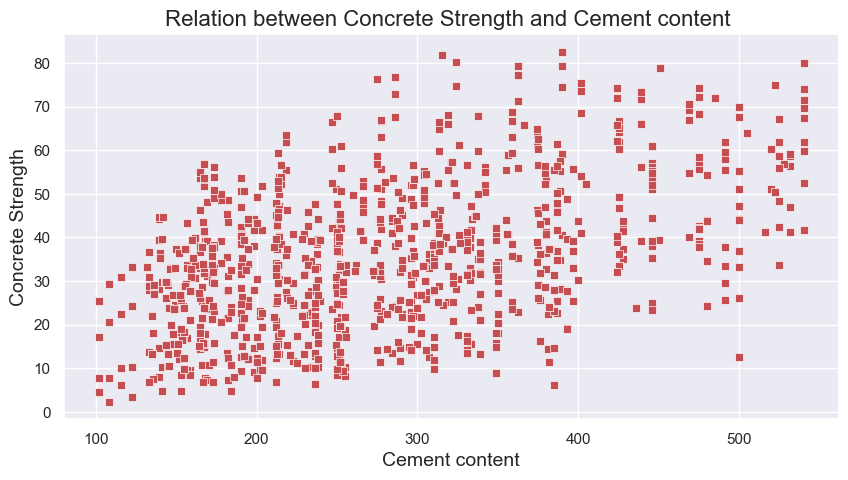

In [23]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = 'Cement', y = 'Strength', data=df, marker = 's', color='r')
plt.title('Relation between Concrete Strength and Cement content ', fontsize=16)
plt.xlabel('Cement content', fontsize=14)
plt.ylabel('Concrete Strength', fontsize=14)
plt.show()

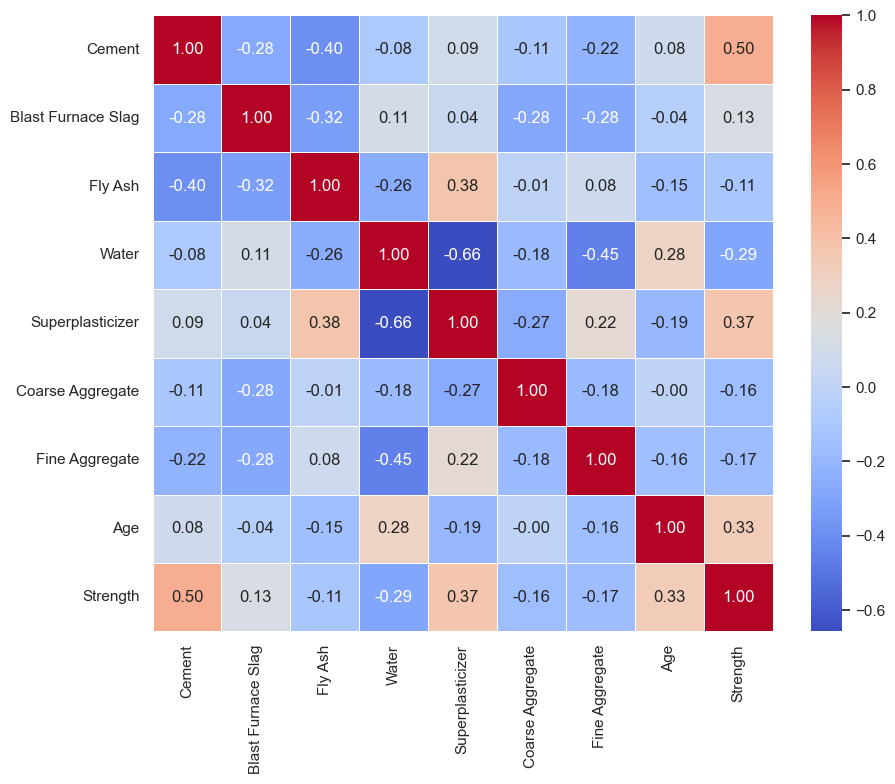

In [24]:
plt.figure(figsize=(10,8))
crr = df.corr()
sns.heatmap(crr, annot=True, cmap = 'coolwarm', fmt = '.2f', linewidths=0.5)
plt.savefig('Heat map of features.png', dpi = 300)
plt.show()

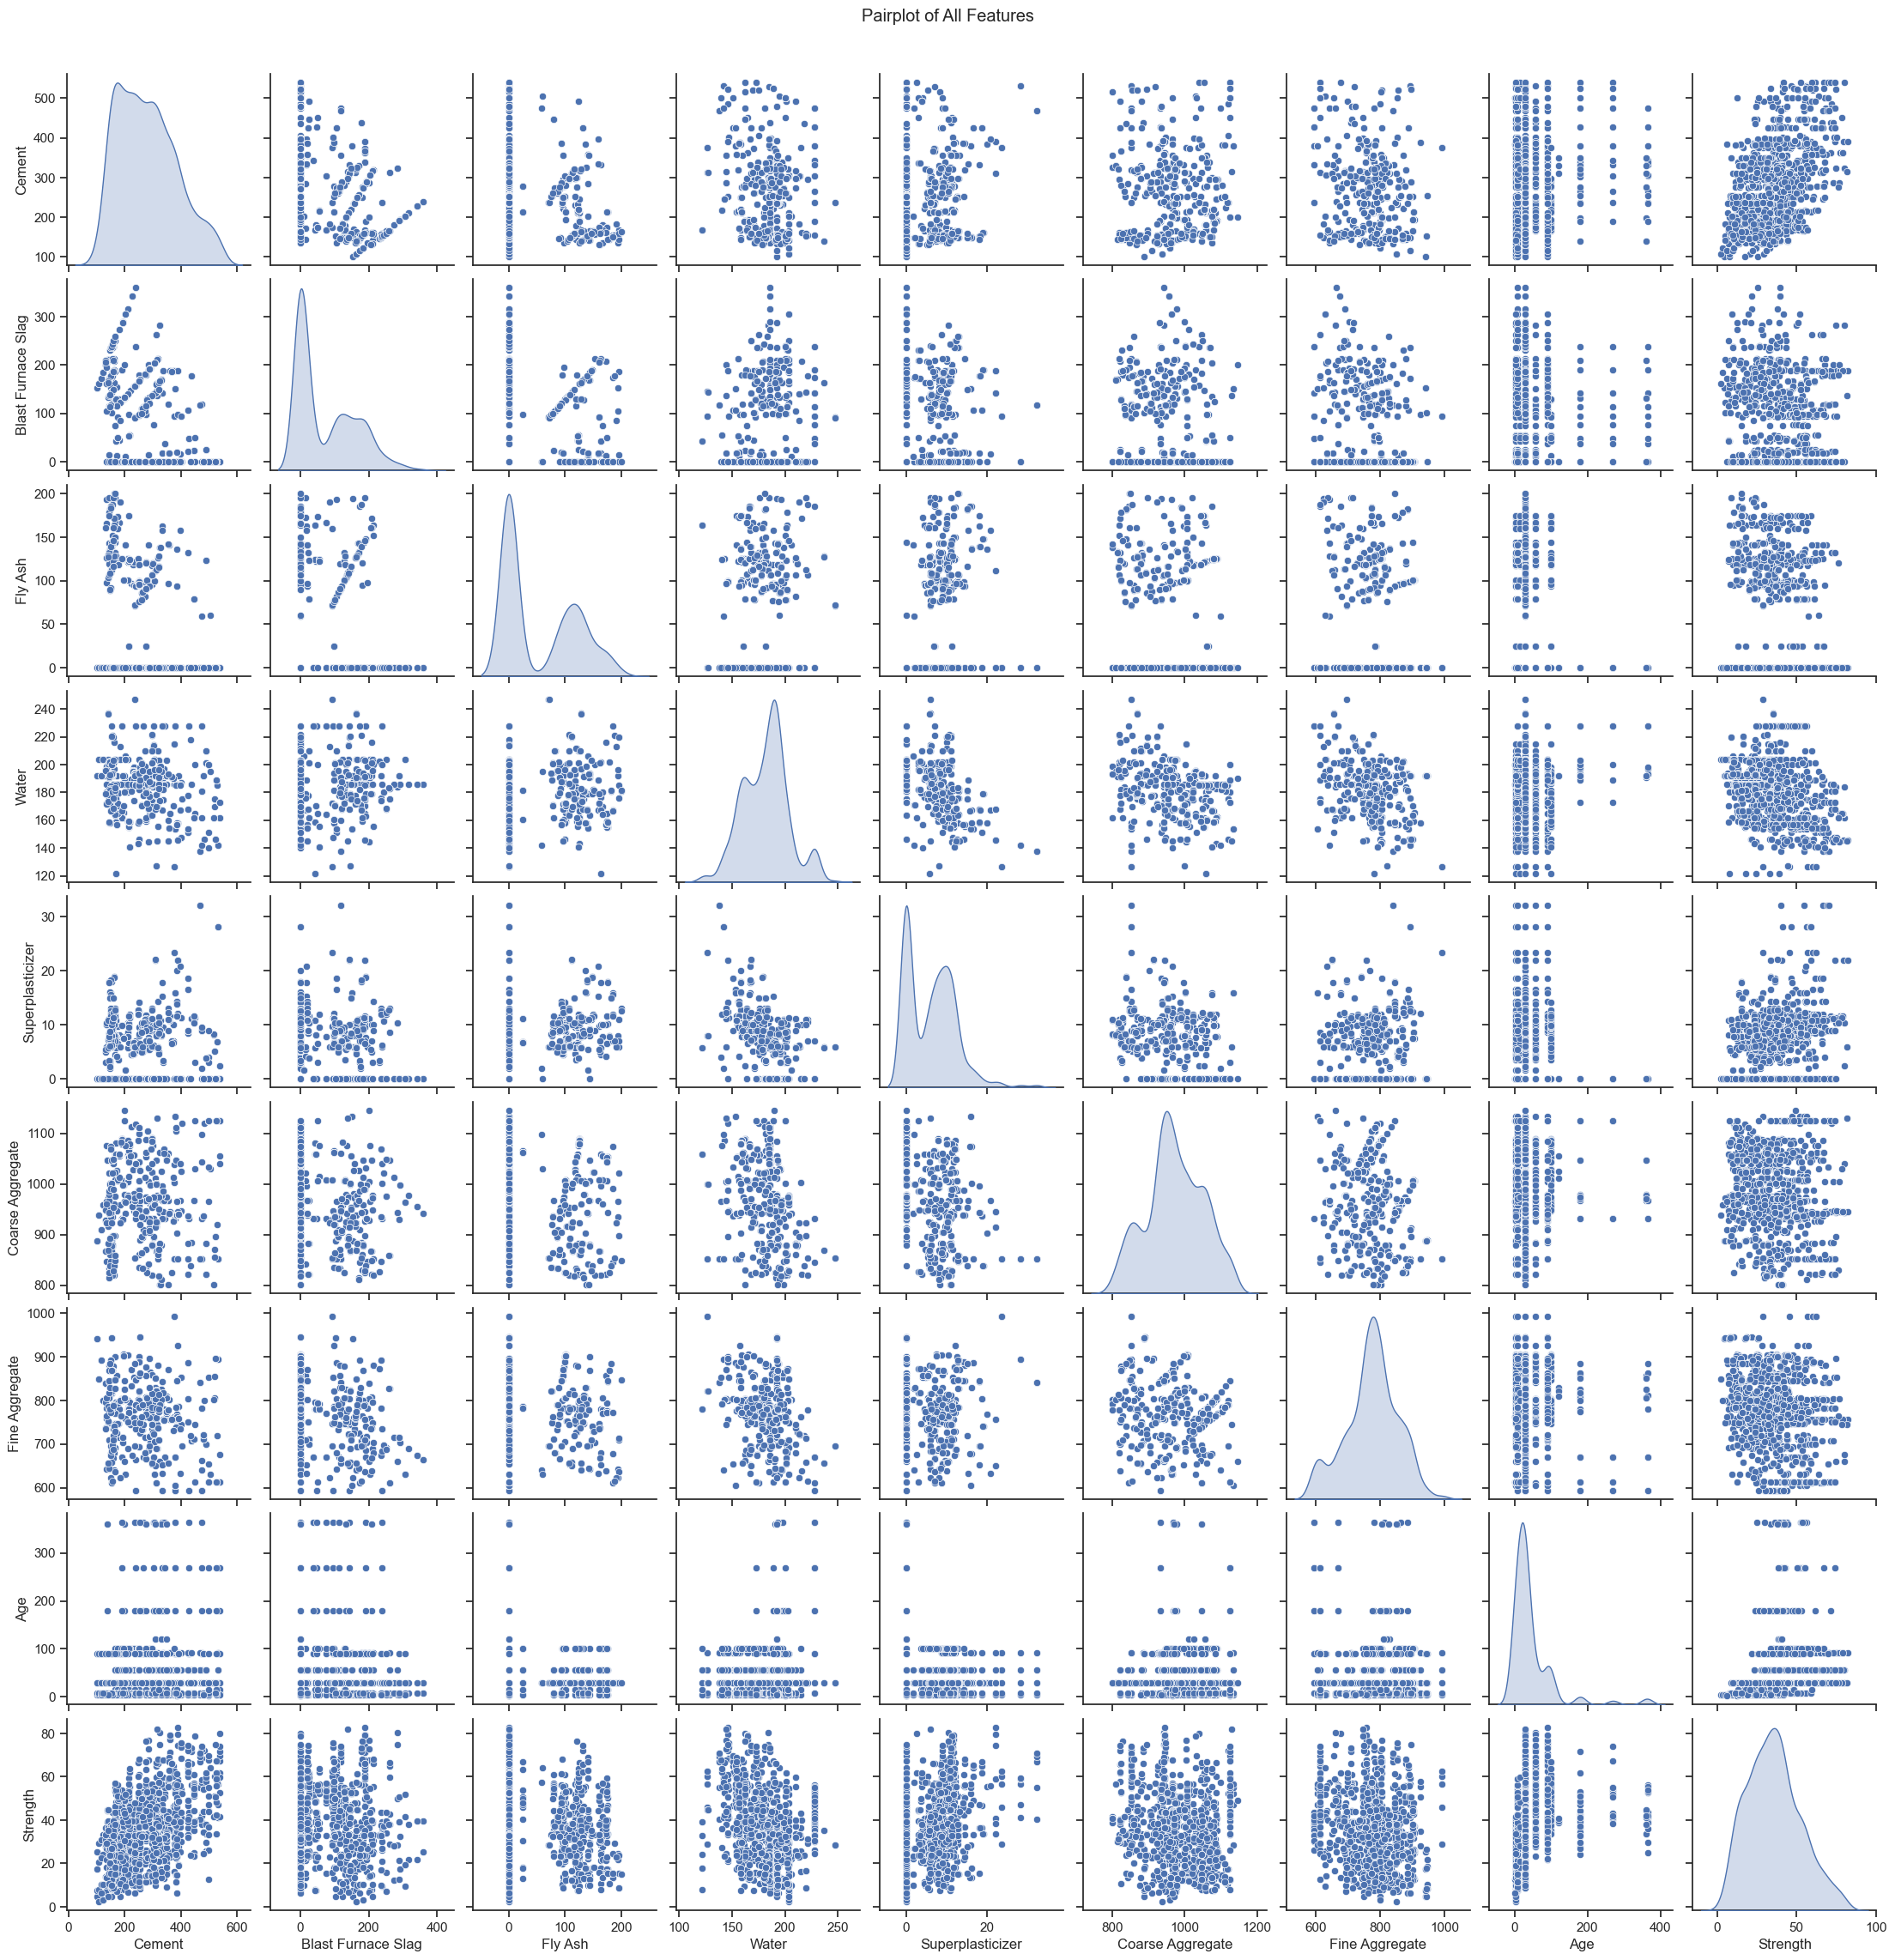

In [25]:
sns.set(style = 'ticks')
pairplot_figure= sns.pairplot(df, diag_kind='kde')
pairplot_figure.fig.suptitle('Pairplot of All Features', y=1.02)
plt.savefig('Pair Plot.png' , dpi = 300,  bbox_inches='tight')
plt.show()

# Find Duplicate value

In [26]:
df.duplicated().value_counts()

False    1005
True       25
Name: count, dtype: int64

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
pd.DataFrame(df.corr()['Strength'].sort_values(ascending=False))

,Strength
Strength,1.000000
Cement,0.488283
Superplasticizer,0.344209
Age,0.337367
Blast Furnace Slag,0.103374
Fly Ash,-0.080648
Coarse Aggregate,-0.144717
Fine Aggregate,-0.186448
Water,-0.269624


# Split data into features and target

In [29]:
X = df.drop(['Strength'], inplace=False, axis = 1)
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [30]:
y = df['Strength']
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1005, dtype: float64

# Split data into train and test data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42, shuffle = True)

In [32]:
pd.DataFrame(X_train)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
79,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3
29,475.0,0.0,0.0,228.0,0.0,932.0,594.0,7
304,277.1,0.0,97.4,160.6,11.8,973.9,875.6,3
531,436.0,0.0,0.0,218.0,0.0,838.4,719.7,28
676,166.8,250.2,0.0,203.5,0.0,975.6,692.6,7
...,...,...,...,...,...,...,...,...
115,337.9,189.0,0.0,174.9,9.5,944.7,755.8,7
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3
885,153.0,145.0,113.0,178.0,8.0,867.0,824.0,28
459,165.0,128.5,132.1,175.1,8.1,1005.8,746.6,100


In [33]:
pd.DataFrame(X_test)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
951,152.7,144.7,0.0,178.1,8.0,999.7,822.2,28
654,122.6,183.9,0.0,203.5,0.0,958.2,800.1,28
706,153.0,102.0,0.0,192.0,0.0,888.0,943.1,90
538,480.0,0.0,0.0,192.0,0.0,936.2,712.2,7
389,500.1,0.0,0.0,200.0,3.0,1124.4,613.2,28
...,...,...,...,...,...,...,...,...
232,213.7,98.1,24.5,181.7,6.9,1065.8,785.4,56
802,339.0,0.0,0.0,185.0,0.0,1060.0,754.0,28
358,277.2,97.8,24.5,160.7,11.2,1061.7,782.5,100
234,213.8,98.1,24.5,181.7,6.7,1066.0,785.5,3


In [34]:
pd.DataFrame(y_train)

,Strength
79,41.30
29,38.60
304,23.14
531,23.85
676,15.75
...,...
115,35.10
294,7.40
885,26.23
459,55.02


In [35]:
pd.DataFrame(y_test)

,Strength
951,19.01
654,24.29
706,26.32
538,34.57
389,44.13
...,...
232,50.77
802,31.65
358,66.95
234,13.18


# Data Scaling / Normalization

In [36]:
scaler = StandardScaler() 
scaler.fit(X_train,y_train) 
X_train_scaled = scaler.transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

# Model Building
## Linear Regression Model

In [37]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [38]:
y_predict = regressor.predict(X_test)

In [39]:
print(f'mean squared error= {mean_squared_error(y_test, y_predict)}')
print(f'mean absolute error= {mean_absolute_error(y_test, y_predict)}')
print(f'r2 score= {r2_score(y_test, y_predict)}')

mean squared error= 125.2456480505019
mean absolute error= 8.895256221464194
r2 score= 0.5801703029028777


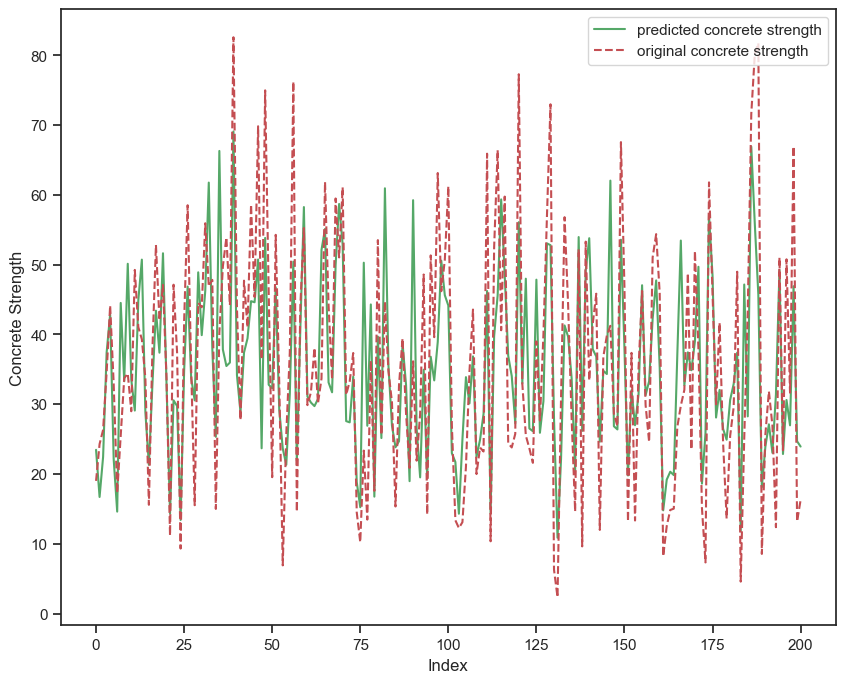

In [40]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'g', label = 'predicted concrete strength')
plt.plot(y_test.values, 'r--', label = 'original concrete strength')
plt.xlabel('Index')
plt.ylabel('Concrete Strength')
plt.legend(loc='upper right')
plt.savefig('12.png', bbox_inches='tight')
plt.show()

## K-Nearest Neighbors (KNN) Model

In [41]:
for i in [1,2,3,4,5,6,7,8,9,10,20]:
    knn = KNeighborsRegressor(i)
    knn.fit(X_train_scaled, y_train)
    train_score = knn.score(X_train_scaled, y_train)
    cv_score = np.mean(cross_val_score(knn, X_train_scaled, y_train, cv = 10))
    print(f"K value: {i}, train_score: {train_score:.4f}, CV score: {cv_score:.4f} ")

K value: 1, train_score: 0.9927, CV score: 0.5928 
K value: 2, train_score: 0.9132, CV score: 0.6206 
K value: 3, train_score: 0.8466, CV score: 0.6545 
K value: 4, train_score: 0.8236, CV score: 0.6618 
K value: 5, train_score: 0.7916, CV score: 0.6586 
K value: 6, train_score: 0.7775, CV score: 0.6547 
K value: 7, train_score: 0.7651, CV score: 0.6473 
K value: 8, train_score: 0.7485, CV score: 0.6380 
K value: 9, train_score: 0.7321, CV score: 0.6383 
K value: 10, train_score: 0.7205, CV score: 0.6342 
K value: 20, train_score: 0.6490, CV score: 0.5923 


In [42]:
Regmodel = KNeighborsRegressor(n_neighbors = 4)
KNN = Regmodel.fit(X_train_scaled, y_train)
y_train_pred = KNN.predict(X_train_scaled)
y_test_pred = KNN.predict(X_test_scaled)

In [43]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"R²: {train_r2:.2f}")
print(f"R²: {test_r2:.2f}")

R²: 0.82
R²: 0.73


## Decision Tree Regressor

In [44]:

max_depths = np.arange(1,20)
for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth = depth, random_state = 42)
    score = np.mean(cross_val_score(tree, X_train, y_train, cv = 5))
    print(f"Depth {depth}: {score:.4f}")

Depth 1: 0.2413
Depth 2: 0.4282
Depth 3: 0.5367
Depth 4: 0.6372
Depth 5: 0.7073
Depth 6: 0.7515
Depth 7: 0.7737
Depth 8: 0.7811
Depth 9: 0.7902
Depth 10: 0.7792
Depth 11: 0.7842
Depth 12: 0.7940
Depth 13: 0.7820
Depth 14: 0.8040
Depth 15: 0.7886
Depth 16: 0.7977
Depth 17: 0.7967
Depth 18: 0.7914
Depth 19: 0.7833


In [45]:
treeregressor = DecisionTreeRegressor(max_depth = 14,random_state = 42, min_samples_split = 4, min_samples_leaf = 3  )
treeregressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=14, min_samples_leaf=3, min_samples_split=4,
                      random_state=42)

In [46]:
y_pred_dtree = treeregressor.predict(X_test)

In [47]:
print(f'r2_score: {r2_score(y_test, y_pred_dtree):.4f}')

r2_score: 0.8660


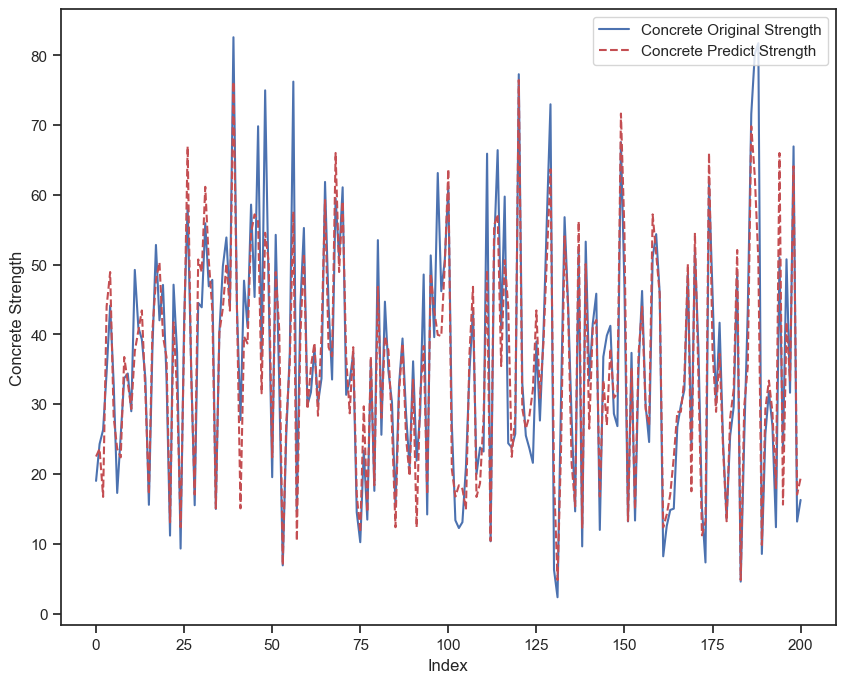

In [48]:
plt.figure(figsize=(10,8))
plt.plot(y_test.values, 'b', label = 'Concrete Original Strength')
plt.plot(y_pred_dtree, 'r--', label = 'Concrete Predict Strength')
plt.xlabel('Index')
plt.ylabel('Concrete Strength')
plt.legend(loc='upper right')
plt.savefig('13.png' , bbox_inches='tight', dpi=300)
plt.show()

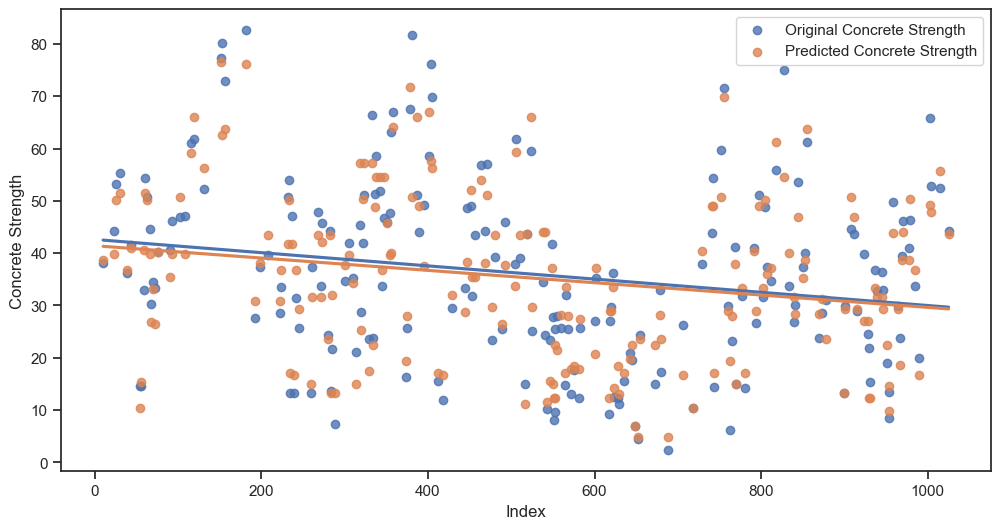

In [49]:
plt.figure(figsize=(12, 6)) 
sns.regplot(x=y_test.index, y=y_test,  label='Original Concrete Strength', ci = None)
sns.regplot(x=y_test.index, y=y_pred_dtree, label='Predicted Concrete Strength', ci = None )
plt.xlabel('Index')
plt.ylabel('Concrete Strength')
plt.legend(loc='upper right')
plt.show()

## Random Forest Regressor

In [50]:
rf = RandomForestRegressor(random_state = 42)

In [51]:
param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [5, 10, 14, 15, 20, 25, None],
    'min_samples_split' : [2,4,5,10],
}
random_search = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_grid,
    n_iter =50,
    cv = 5,
    random_state = 42,
    n_jobs = -1
)

In [52]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 14, 15, 20, 25,
                                                      None],
                                        'min_samples_split': [2, 4, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42)

In [53]:
print("Best Parameters: ", random_search.best_params_)

Best Parameters:  {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 15}


In [54]:
y_pred_rf = random_search.predict(X_test)

In [55]:
print(f'r2_score: {r2_score(y_test, y_pred_rf):.4f}')

r2_score: 0.9100


## XGBoost Regressor

In [56]:
xgb_model = xgb.XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 8,
    random_state = 42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [57]:
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb= xgb_model.predict(X_test)

In [58]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred_xgb)

print(f"Train R²: {train_r2:.3f}")
print(f"Test  R²: {test_r2:.3f}")

Train R²: 0.824
Test  R²: 0.925


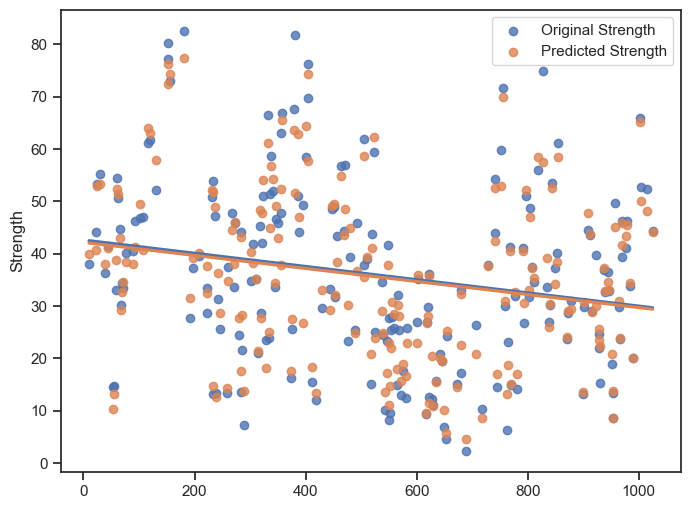

In [59]:
plt.figure(figsize=(8,6))
sns.regplot(x = y_test.index, y = y_test, label = 'Original Strength', ci = None)
sns.regplot(x = y_test.index, y = y_test_pred_xgb , label = 'Predicted Strength', ci = None)
plt.legend(loc='upper right')
plt.show()

# Model Comparison (Table and Plots)

In [60]:
df_score = {
    'Model' : ['Linear Model', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'MSE' : [mean_squared_error(y_test, y_predict), mean_squared_error(y_test, y_test_pred), mean_squared_error(y_test, y_pred_dtree),
            mean_squared_error(y_test, y_pred_rf ), mean_squared_error(y_test, y_test_pred_xgb)],
    'MAE' : [mean_absolute_error(y_test, y_predict), mean_absolute_error(y_test, y_test_pred), mean_absolute_error(y_test, y_pred_dtree),
            mean_absolute_error(y_test, y_pred_rf), mean_absolute_error(y_test, y_test_pred_xgb)],
    'R2 Score' : [r2_score(y_test, y_predict), r2_score(y_test, y_test_pred), r2_score(y_test, y_pred_dtree), 
                 r2_score(y_test, y_pred_rf), r2_score(y_test, y_test_pred_xgb)]
}

In [61]:
df_score = pd.DataFrame(df_score)
df_score

,Model,MSE,MAE,R2 Score
0,Linear Model,125.245648,8.895256,0.580170
1,KNN,81.447221,6.820659,0.726985
2,Decision Tree,39.964504,4.569408,0.866037
3,Random Forest,26.845081,3.502511,0.910014
4,XGBoost,22.368497,3.018871,0.925020


C:\Users\User\AppData\Local\Temp\ipykernel_18108\632013176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.barplot(x='Model', y='R2 Score', data=df_score , palette='Blues_d')


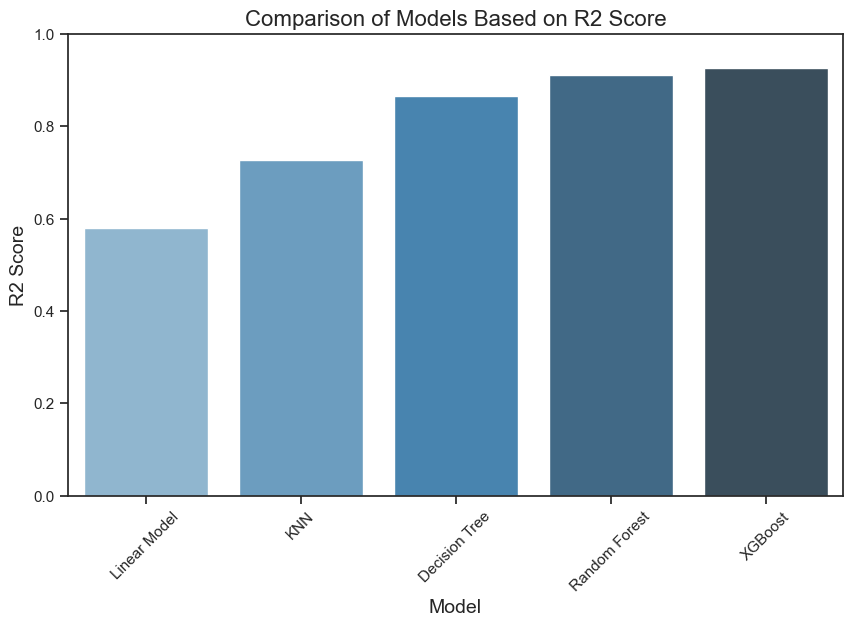

<Figure size 640x480 with 0 Axes>

In [64]:
sns.set(style="ticks")

# Plot
plt.figure(figsize=(10,6))
figure = sns.barplot(x='Model', y='R2 Score', data=df_score , palette='Blues_d')
plt.title('Comparison of Models Based on R2 Score', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('R2 Score', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()
plt.savefig('modelcomparison.png', dpi=300)

# Predict Concrete Strength according to XGBoost Regressor

In [63]:
print(xgb_model.predict([[350,0,0,200,0,800,550,28]]))
print(xgb_model.predict([[300,100,100,10,100,950,650,28]]))
print(xgb_model.predict([[250,300,50,15,100,1100,900,28]]))
print(xgb_model.predict([[250,30,150,25,100,1000,800,28]]))

[33.55892]
[43.41201]
[60.130043]
[46.926815]
